# Peyrache Lab — Synchronization Exploration

This notebook visualizes how the three recording systems are synchronized:
- **Intan RHD** (master clock, 20 kHz)
- **UCLA Miniscope V4** (calcium imaging, ~24.6 FPS actual)
- **OptiTrack Motive** (3D tracking, 120 FPS)

The Intan records two analog sync signals on its ADC inputs:
- **ADC-00**: OptiTrack TTL — 120 Hz, **0.5 ms** pulse per frame
- **ADC-01**: Miniscope frame gate — square wave, one cycle (HIGH→LOW) = 2 Miniscope frames

**Sample session**: A0662 / 2022-07-28

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({"figure.dpi": 150, "axes.spines.top": False, "axes.spines.right": False})

# ── colour palette ───────────────────────────────────────────────────────────
C_INTAN = "#4C72B0"   # blue  — Intan / neutral
C_OPT   = "#C44E52"   # red   — OptiTrack  (ADC-00)
C_MS    = "#55A868"   # green — Miniscope  (ADC-01)
C_USB   = "#9ECAE1"   # light blue — USB timestamps

# ── paths ────────────────────────────────────────────────────────────────────
SESSION = Path("~/source_data/peyrache-lab/A0662/2022_07_28").expanduser()
if not SESSION.exists():
    SCRATCH = Path("/private/tmp/claude-501/-Users-weian-catalystneuro/"
                   "6b8f0ff1-8e9d-4c81-af22-768db9270017/scratchpad/peyrache_sample")
    SESSION_INTAN    = SCRATCH / "session2/intan"
    SESSION_MS_TS    = SCRATCH / "session2/timeStamps.csv"
    SESSION_TRACKING = SCRATCH / "tracking/Take 2022-07-25 02.28.38 PM.csv"
else:
    SESSION_INTAN    = SESSION / "Intan"
    SESSION_MS_TS    = SESSION / "Miniscope/timeStamps.csv"
    SESSION_TRACKING = next((SESSION / "Tracking").glob("Take *.csv"))

print("Intan dir:",    SESSION_INTAN)
print("Miniscope TS:", SESSION_MS_TS)

Intan dir: /Users/weian/source_data/peyrache-lab/A0662/2022_07_28/Intan
Miniscope TS: /Users/weian/source_data/peyrache-lab/A0662/2022_07_28/Miniscope/timeStamps.csv


In [2]:
# ── Load and decode Intan ────────────────────────────────────────────────────
SR    = 20_000
DT    = 1.0 / SR          # 0.05 ms per sample

time_s  = np.fromfile(SESSION_INTAN / "time.dat",    dtype=np.int32)  / SR
adc_raw = np.fromfile(SESSION_INTAN / "analogin.dat", dtype=np.uint16)
n_ch    = adc_raw.size // time_s.size
adc_v   = adc_raw.reshape(time_s.size, n_ch).astype(np.float32) * (3.3 / 65535.0)

print(f"Intan: {time_s.size:,} samples  ·  {time_s[-1]:.1f} s  ·  {n_ch} ADC channels")

# ── Edge detection ───────────────────────────────────────────────────────────
THRESH = 1.0
def rising(v):  return np.where(np.diff((v > THRESH).astype(np.int8)) ==  1)[0]
def falling(v): return np.where(np.diff((v > THRESH).astype(np.int8)) == -1)[0]

ch0_r = rising(adc_v[:, 0]);  ch0_f = falling(adc_v[:, 0])   # OptiTrack
ch1_r = rising(adc_v[:, 1]);  ch1_f = falling(adc_v[:, 1])   # Miniscope

# Per-frame timestamps in Intan clock
opt_ts  = time_s[ch0_r]                          # one entry per OptiTrack frame
n       = min(len(ch1_r), len(ch1_f))
ms_hw   = np.empty(2 * n)                        # one entry per Miniscope frame
ms_hw[0::2] = time_s[ch1_r[:n]]                 # even frames ← rising edge
ms_hw[1::2] = time_s[ch1_f[:n]]                 # odd frames  ← falling edge

# Miniscope USB timestamps
ms_df  = pd.read_csv(SESSION_MS_TS)
ms_usb = ms_df["Time Stamp (ms)"].values / 1000.0

print(f"Miniscope frames (HW): {len(ms_hw):,}   OptiTrack synced: {len(opt_ts):,}")
print(f"ADC-00 → OptiTrack  ({1/np.diff(opt_ts).mean():.1f} Hz, "
      f"{np.diff(time_s[ch0_r[:100]] - time_s[ch0_f[:100]]).mean()*0 + (time_s[ch0_f[0]]-time_s[ch0_r[0]])*1000:.1f} ms pulse)")
print(f"ADC-01 → Miniscope  ({1/np.diff(ms_hw).mean():.2f} Hz effective, "
      f"{(time_s[ch1_f[0]]-time_s[ch1_r[0]])*1000:.1f} ms pulse)")

Intan: 24,158,160 samples  ·  1207.9 s  ·  2 ADC channels


Miniscope frames (HW): 29,568   OptiTrack synced: 144,444
ADC-00 → OptiTrack  (120.0 Hz, 0.5 ms pulse)
ADC-01 → Miniscope  (24.64 Hz effective, 40.6 ms pulse)


In [3]:
# ── Envelope helper ──────────────────────────────────────────────────────────
# Fast min/max envelope that avoids aliasing when many samples map to one pixel.
# Splits the signal into `n_bins` segments, takes min and max of each, and
# fills the band between them — so even a 0.5 ms pulse stays visible.

def plot_envelope(ax, t, v, color, n_bins=4000, alpha_fill=0.85,
                  lw=0.0, label=None, zorder=2):
    """Plot min/max envelope of (t, v); avoids aliasing for dense signals."""
    idx  = np.linspace(0, len(t) - 1, n_bins + 1, dtype=int)
    t_b  = t[idx[:-1]]                         # left edge of each bin
    vmin = np.array([v[idx[i]:idx[i+1]].min() for i in range(n_bins)])
    vmax = np.array([v[idx[i]:idx[i+1]].max() for i in range(n_bins)])
    ax.fill_between(t_b, vmin, vmax, color=color, alpha=alpha_fill,
                    lw=lw, label=label, zorder=zorder, rasterized=True)

## 1 — Full session overview

20-minute session. The ADC signals are rendered as min/max envelopes so even the 0.5 ms OptiTrack pulses remain visible as a dense texture.

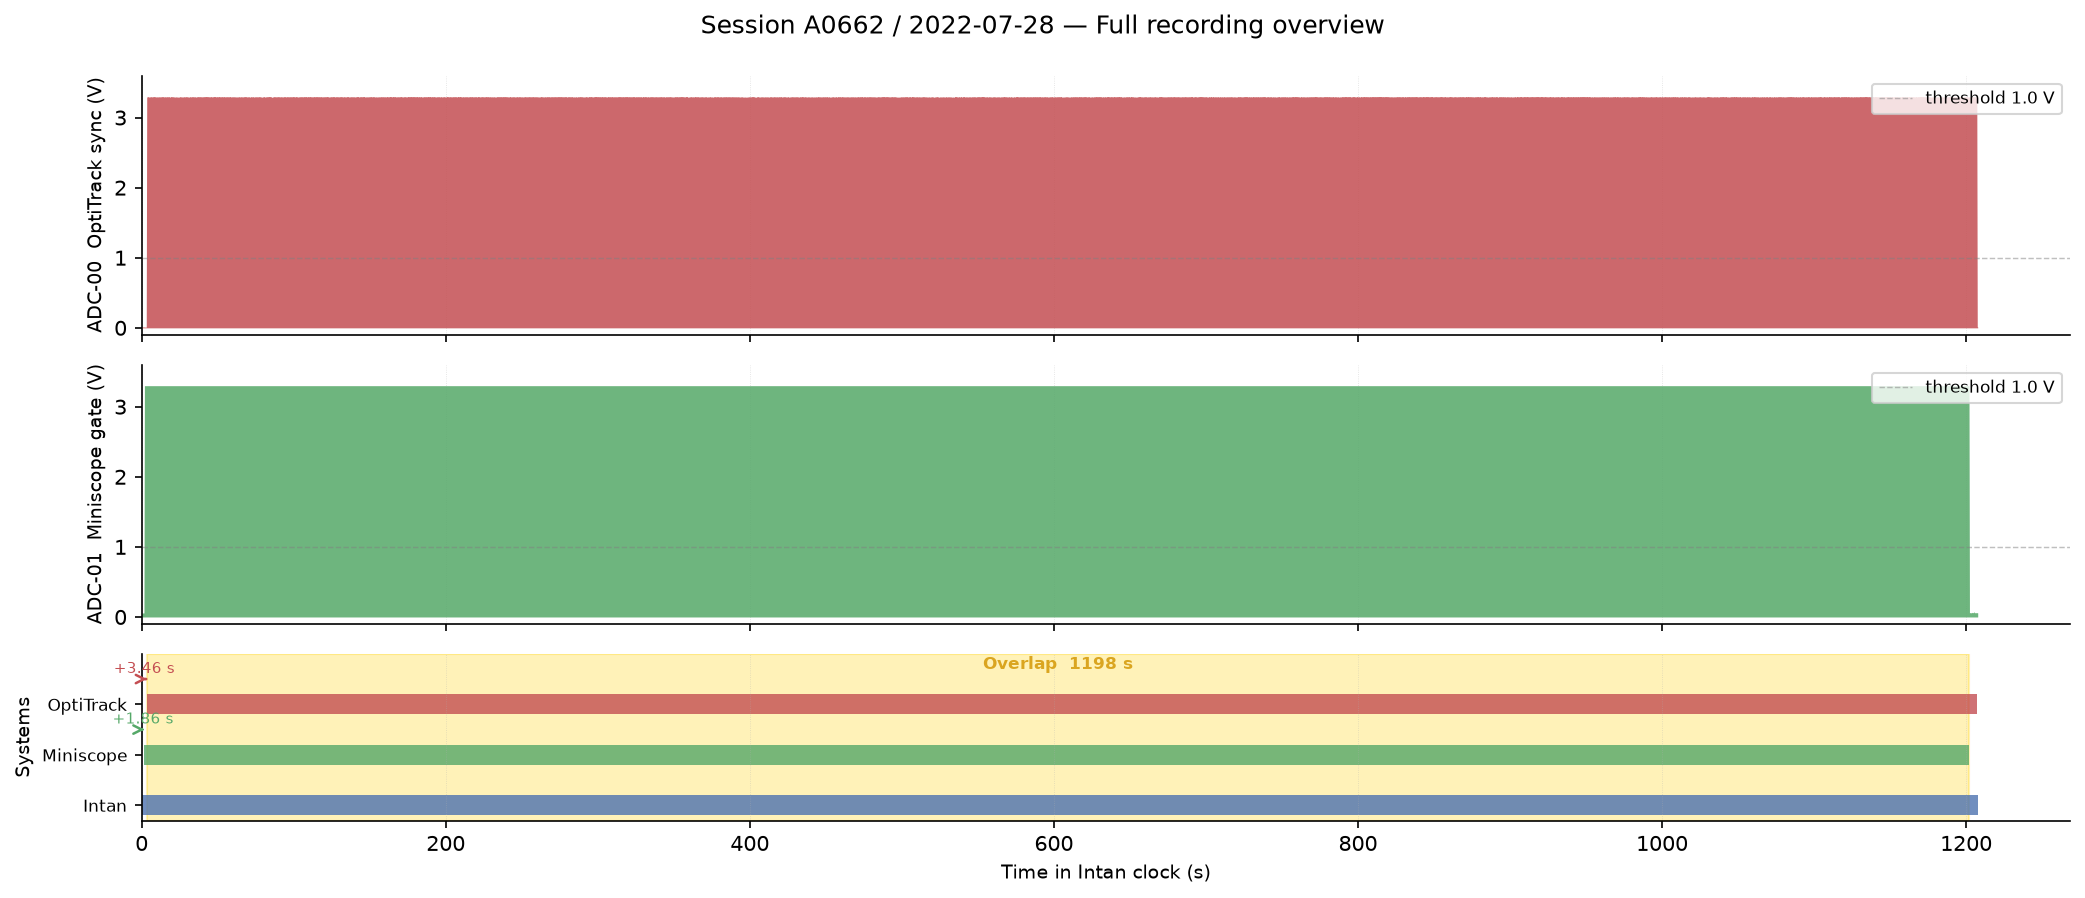

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw=dict(height_ratios=[1.4, 1.4, 0.9]))
fig.suptitle("Session A0662 / 2022-07-28 — Full recording overview",
             fontsize=12, y=0.99)

for ax, ch, color, label in zip(
    axes[:2],
    [0, 1],
    [C_OPT, C_MS],
    ["ADC-00  OptiTrack sync (V)", "ADC-01  Miniscope gate (V)"]
):
    plot_envelope(ax, time_s, adc_v[:, ch], color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(-0.1, 3.6)
    ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5,
               label=f"threshold {THRESH} V")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(axis="x", ls=":", lw=0.4, alpha=0.4)

# Panel 3 — active-period bars + overlap highlight
ax = axes[2]
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Intan", "Miniscope", "OptiTrack"], fontsize=8)

ax.barh(0, time_s[-1]     - time_s[0],    left=time_s[0],    height=0.4, color=C_INTAN, alpha=0.8)
ax.barh(1, ms_hw[-1]      - ms_hw[0],     left=ms_hw[0],     height=0.4, color=C_MS,    alpha=0.8)
ax.barh(2, opt_ts[-1]     - opt_ts[0],    left=opt_ts[0],    height=0.4, color=C_OPT,   alpha=0.8)

ol_s = max(ms_hw[0], opt_ts[0])
ol_e = min(ms_hw[-1], opt_ts[-1])
for row in range(3):
    ax.axvspan(ol_s, ol_e, alpha=0.10, color="gold", zorder=0)
ax.text((ol_s + ol_e) / 2, 2.62,
        f"Overlap  {ol_e - ol_s:.0f} s",
        ha="center", va="bottom", fontsize=8, color="goldenrod", fontweight="bold")

# Start-lag annotations
ax.annotate("", xy=(ms_hw[0], 1.5), xytext=(time_s[0], 1.5),
            arrowprops=dict(arrowstyle="->", color=C_MS, lw=1.2))
ax.text(ms_hw[0] / 2, 1.62, f"+{ms_hw[0]:.2f} s", fontsize=7, color=C_MS, ha="center")

ax.annotate("", xy=(opt_ts[0], 2.5), xytext=(time_s[0], 2.5),
            arrowprops=dict(arrowstyle="->", color=C_OPT, lw=1.2))
ax.text(opt_ts[0] / 2, 2.62, f"+{opt_ts[0]:.2f} s", fontsize=7, color=C_OPT, ha="center")

ax.set_ylim(-0.3, 3.0)
ax.set_ylabel("Systems", fontsize=9)
ax.grid(axis="x", ls=":", lw=0.4, alpha=0.4)
axes[2].set_xlabel("Time in Intan clock (s)", fontsize=9)

plt.tight_layout()
plt.savefig("sync_01_full_session.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 — Session start: startup sequence

First 8 seconds. ADC-00 (OptiTrack, 0.5 ms pulses) uses envelope rendering so pulses are not aliased away. ADC-01 (Miniscope, 40 ms pulses) is wide enough to show at raw resolution.

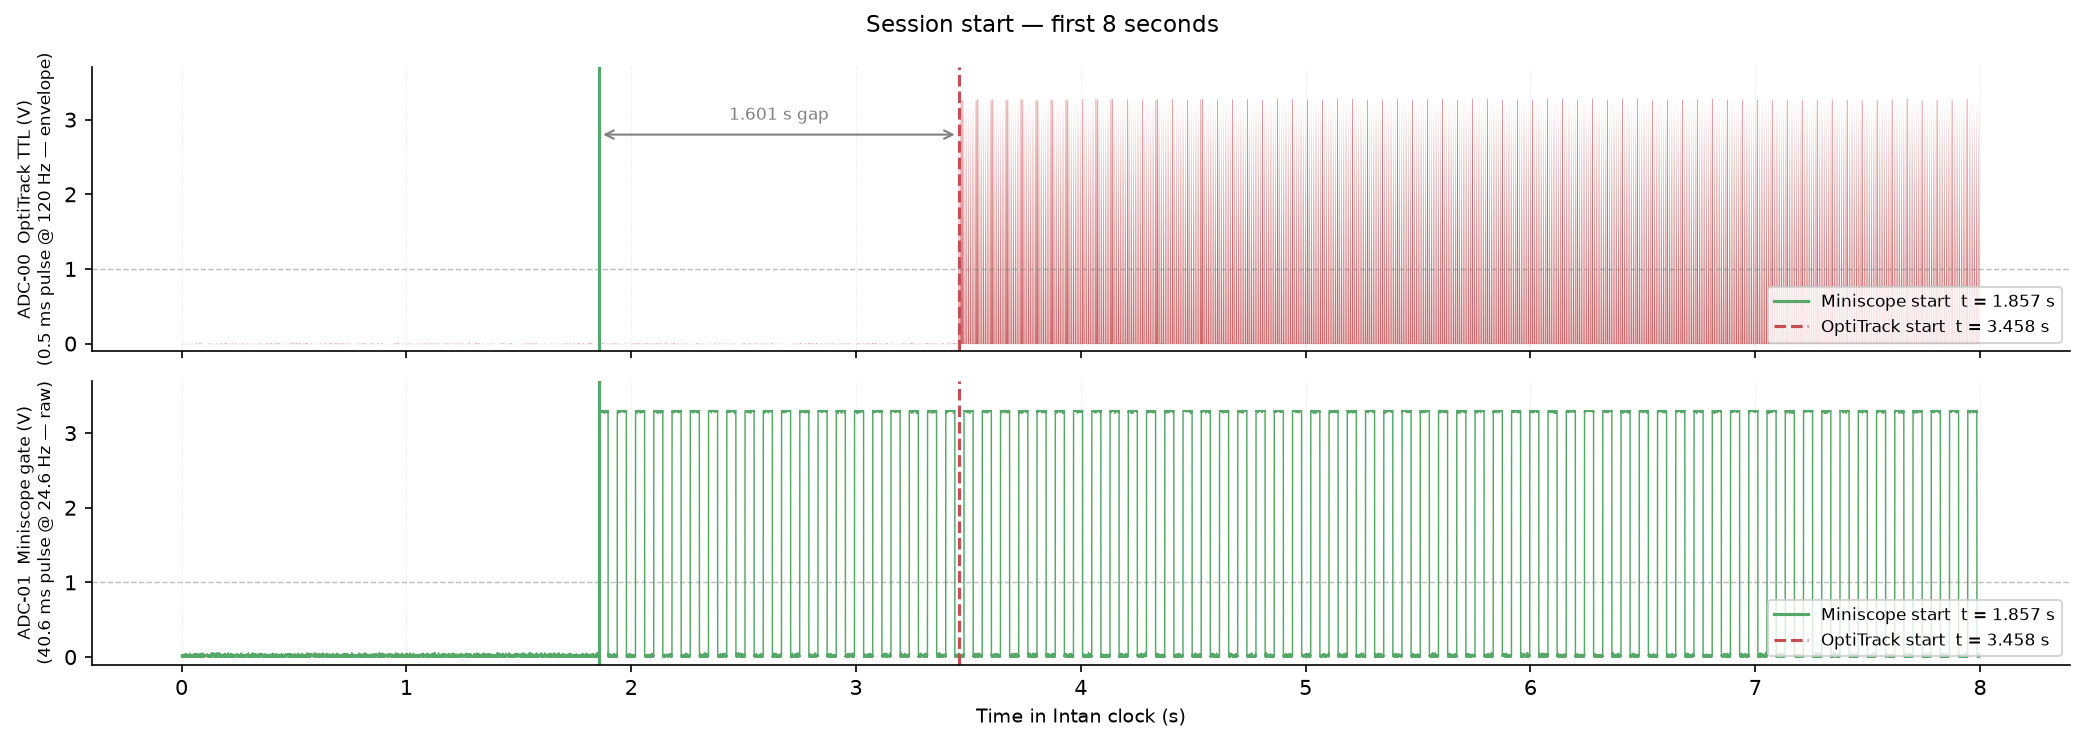

In [5]:
T0_zoom, T1_zoom = 0.0, 8.0
mask_z = (time_s >= T0_zoom) & (time_s <= T1_zoom)
t_z    = time_s[mask_z]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle("Session start — first 8 seconds", fontsize=11)

# ADC-00 (OptiTrack): must use envelope — pulses are only 0.5 ms wide
ax = axes[0]
plot_envelope(ax, t_z, adc_v[mask_z, 0], color=C_OPT, n_bins=3000)
ax.set_ylabel("ADC-00  OptiTrack TTL (V)\n(0.5 ms pulse @ 120 Hz — envelope)", fontsize=8)
ax.set_ylim(-0.1, 3.7)
ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5)

# ADC-01 (Miniscope): 40 ms pulses are wide enough to see directly
ax = axes[1]
ax.plot(t_z, adc_v[mask_z, 1], lw=0.7, color=C_MS, rasterized=True)
ax.set_ylabel("ADC-01  Miniscope gate (V)\n(40.6 ms pulse @ 24.6 Hz — raw)", fontsize=8)
ax.set_ylim(-0.1, 3.7)
ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5)

# Mark system starts on both panels
for ax in axes:
    ax.axvline(ms_hw[0],  color=C_MS,  lw=1.5, ls="-",
               label=f"Miniscope start  t = {ms_hw[0]:.3f} s")
    ax.axvline(opt_ts[0], color=C_OPT, lw=1.5, ls="--",
               label=f"OptiTrack start  t = {opt_ts[0]:.3f} s")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", ls=":", lw=0.4, alpha=0.4)

# Annotate the gap between Miniscope and OptiTrack starts
ax = axes[0]
ax.annotate("", xy=(opt_ts[0], 2.8), xytext=(ms_hw[0], 2.8),
            arrowprops=dict(arrowstyle="<->", color="gray", lw=1.0))
ax.text((ms_hw[0] + opt_ts[0]) / 2, 3.0,
        f"{opt_ts[0] - ms_hw[0]:.3f} s gap",
        ha="center", fontsize=8, color="gray")

axes[1].set_xlabel("Time in Intan clock (s)", fontsize=9)
plt.tight_layout()
plt.savefig("sync_02_session_start.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 — Pulse shapes at single-frame resolution

A 0.5-second window after both systems are active. At this zoom:
- **ADC-01**: Miniscope 40 ms square-wave pulses are easily read
- **ADC-00**: OptiTrack 0.5 ms spikes appear as thin vertical lines (each just 10 Intan samples wide)

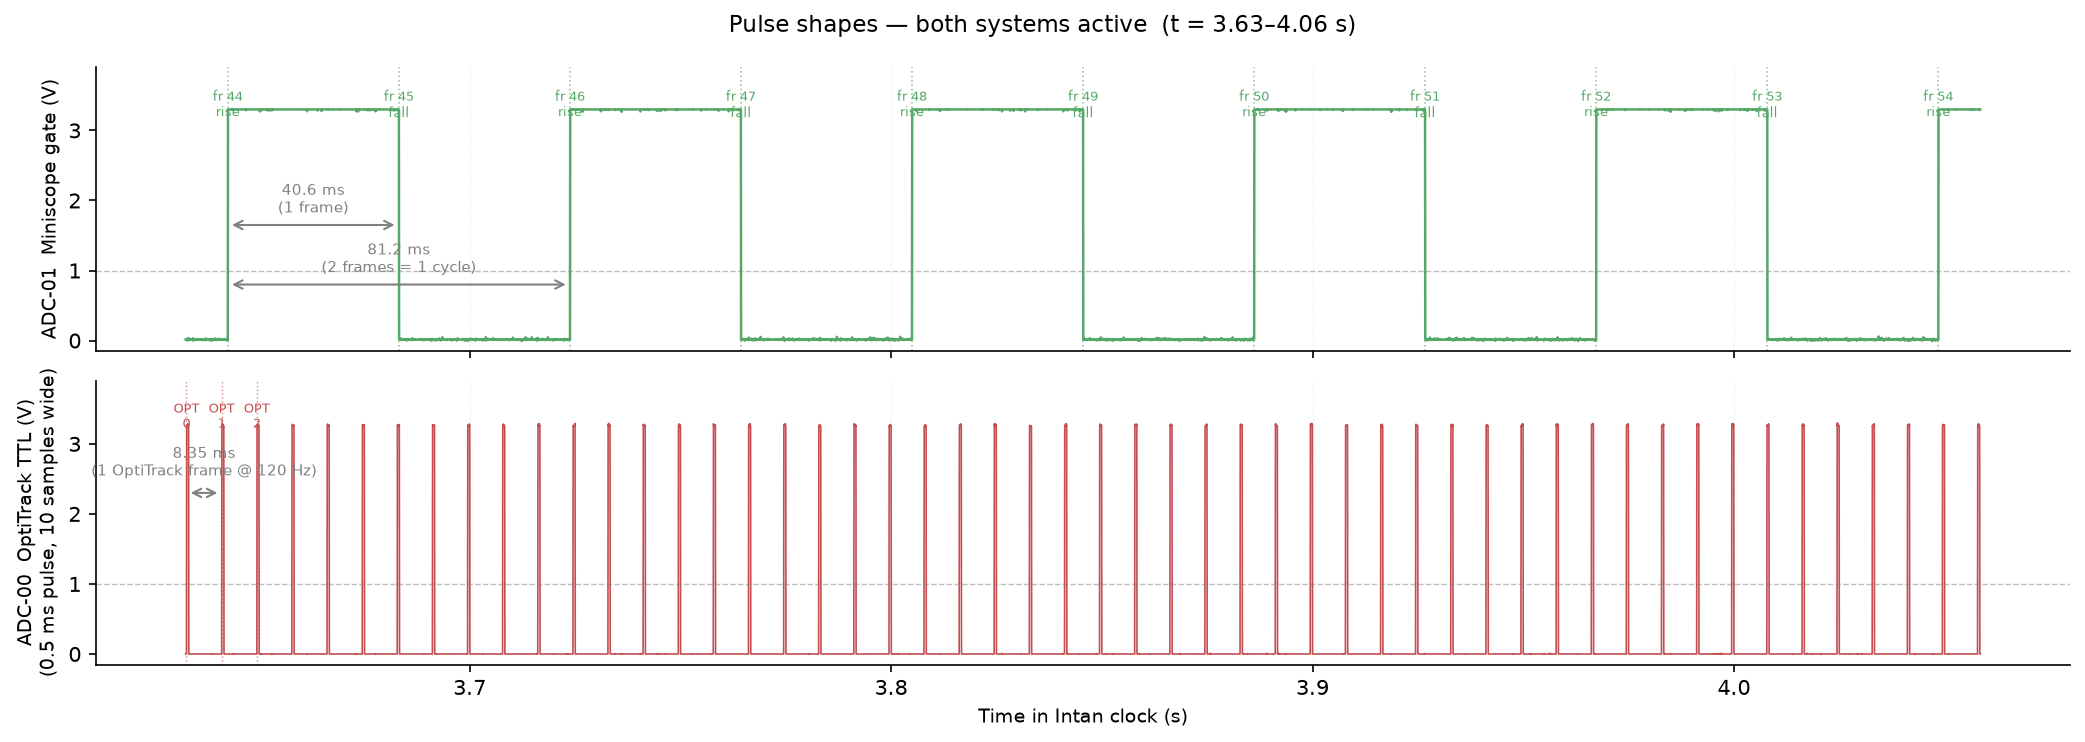

Window: 3.633 – 4.058 s   (11 Miniscope frames, 52 OptiTrack frames)


In [6]:
# Pick a window after BOTH systems are active (OptiTrack starts at ~3.46 s).
# Use the 22nd Miniscope rising edge, which is ~1.8 s after the first and
# lands ~3.65 s into the session — safely past the OptiTrack start.
WIN_EDGE = 22   # Miniscope rising-edge index
T_WIN_S  = time_s[ch1_r[WIN_EDGE]]     - 0.01
T_WIN_E  = time_s[ch1_r[WIN_EDGE + 5]] + 0.01   # 5 Miniscope cycles ≈ 0.41 s
mask_w   = (time_s >= T_WIN_S) & (time_s <= T_WIN_E)
t_w      = time_s[mask_w]

opt_in_w = opt_ts[(opt_ts >= T_WIN_S) & (opt_ts <= T_WIN_E)]
ms_in_w  = ms_hw[ (ms_hw  >= T_WIN_S) & (ms_hw  <= T_WIN_E)]
ms_idx0  = np.searchsorted(ms_hw, T_WIN_S)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle(
    f"Pulse shapes — both systems active  (t = {T_WIN_S:.2f}–{T_WIN_E:.2f} s)",
    fontsize=11)

# ADC-01 — Miniscope frame gate (slow, raw plot works fine)
ax = axes[0]
ax.plot(t_w, adc_v[mask_w, 1], lw=1.2, color=C_MS)
ax.set_ylabel("ADC-01  Miniscope gate (V)", fontsize=9)
ax.set_ylim(-0.15, 3.9)
ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5)

for k, t in enumerate(ms_in_w):
    fidx = ms_idx0 + k
    edge = "rise" if fidx % 2 == 0 else "fall"
    ax.axvline(t, color=C_MS, lw=0.8, ls=":", alpha=0.6)
    ax.text(t, 3.6, f"fr {fidx}\n{edge}",
            ha="center", va="top", fontsize=6, color=C_MS)

# Annotate 1-frame and 2-frame durations
t0, t1, t2 = ms_in_w[:3]
for ypos, ta, tb, lbl in [
    (1.65, t0, t1, f"{(t1-t0)*1000:.1f} ms\n(1 frame)"),
    (0.80, t0, t2, f"{(t2-t0)*1000:.1f} ms\n(2 frames = 1 cycle)"),
]:
    ax.annotate("", xy=(tb, ypos), xytext=(ta, ypos),
                arrowprops=dict(arrowstyle="<->", color="gray", lw=1.0))
    ax.text((ta+tb)/2, ypos + 0.18, lbl, ha="center", fontsize=7, color="gray")

ax.grid(axis="x", ls=":", lw=0.4, alpha=0.4)

# ADC-00 — OptiTrack TTL (raw plot: 0.5 ms pulses are ~10 samples wide;
# at this zoom level they appear as thin vertical spikes)
ax = axes[1]
ax.plot(t_w, adc_v[mask_w, 0], lw=0.8, color=C_OPT)
ax.set_ylabel("ADC-00  OptiTrack TTL (V)\n(0.5 ms pulse, 10 samples wide)", fontsize=9)
ax.set_ylim(-0.15, 3.9)
ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5)

# Annotate a few OptiTrack pulses
for k, t in enumerate(opt_in_w[:3]):
    ax.axvline(t, color=C_OPT, lw=0.7, ls=":", alpha=0.6)
    ax.text(t, 3.6, f"OPT\n{k}", ha="center", va="top", fontsize=6, color=C_OPT)

if len(opt_in_w) >= 2:
    t0o, t1o = opt_in_w[0], opt_in_w[1]
    ax.annotate("", xy=(t1o, 2.3), xytext=(t0o, 2.3),
                arrowprops=dict(arrowstyle="<->", color="gray", lw=1.0))
    ax.text((t0o+t1o)/2, 2.55,
            f"{(t1o-t0o)*1000:.2f} ms\n(1 OptiTrack frame @ 120 Hz)",
            ha="center", fontsize=7, color="gray")

ax.set_xlabel("Time in Intan clock (s)", fontsize=9)
ax.grid(axis="x", ls=":", lw=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("sync_03_pulse_shapes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Window: {T_WIN_S:.3f} – {T_WIN_E:.3f} s   "
      f"({len(ms_in_w)} Miniscope frames, {len(opt_in_w)} OptiTrack frames)")

## 4 — Miniscope USB timestamps: not jitter, but clock drift

The Miniscope records frame *arrival* times on the USB bus (`timeStamps.csv`), not actual camera *exposure* times.
Comparing those USB timestamps against the hardware Ch1 signal reveals a **systematic linear drift** between the two clocks — not random noise.

Over the 20-minute session the two clocks diverge by ~300 ms total (~250 ppm rate difference).
The hardware sync channel is the only reliable per-frame timestamp source.

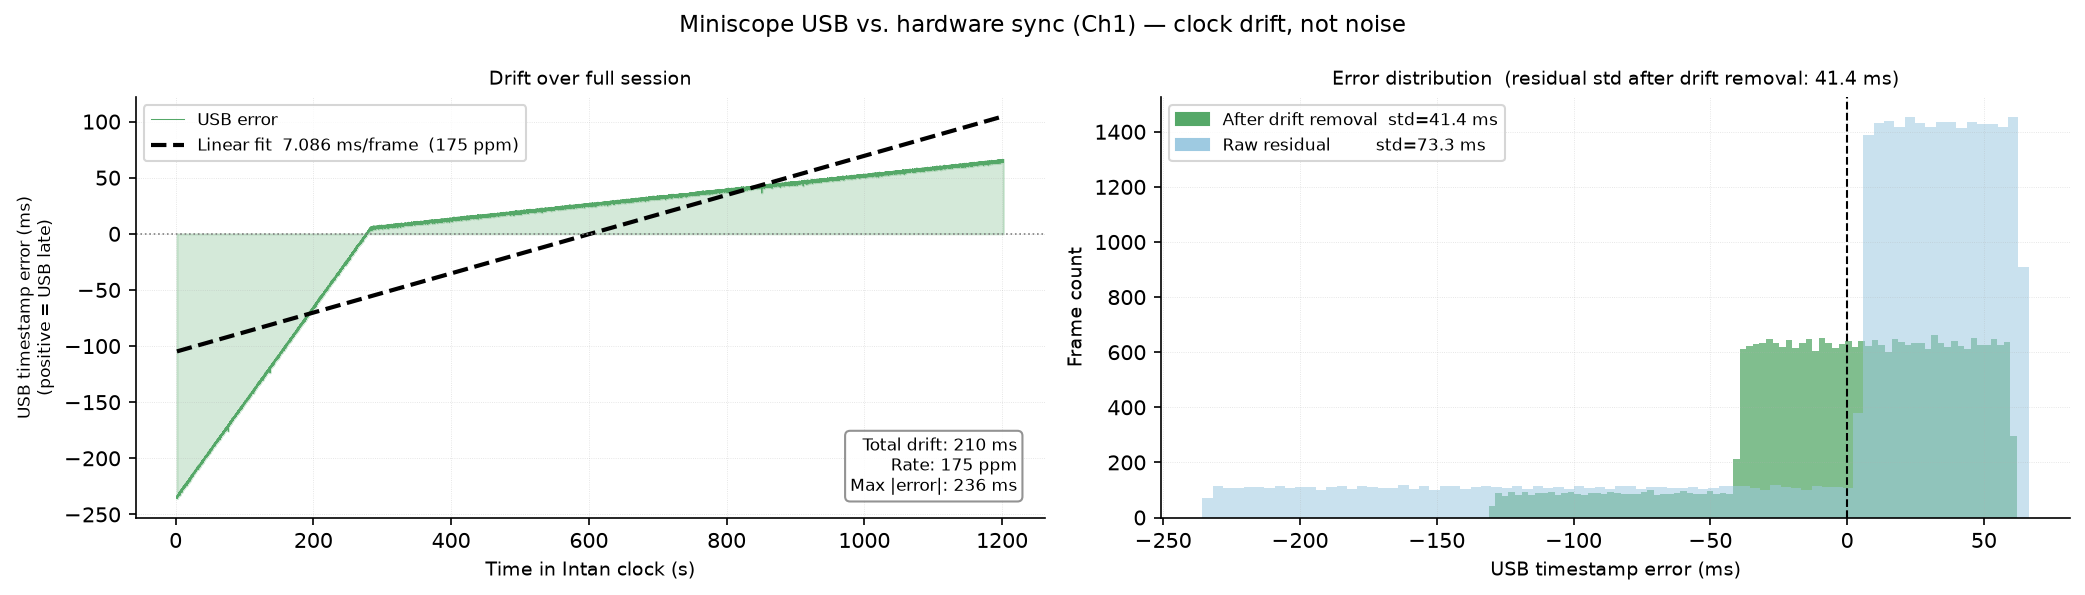

Clock drift rate : 7.0858 ms / frame  =  175 ppm
Total drift      : 209.5 ms over 1200 s
→ Cannot correct with a fixed offset — need per-frame hardware timestamps.


In [7]:
n_check   = min(len(ms_hw), len(ms_usb))
raw_diff  = ms_hw[:n_check] - ms_usb[:n_check]   # Intan_hw − USB
mean_off  = raw_diff.mean()
residual  = (raw_diff - mean_off) * 1000          # ms, mean-centred

frames = np.arange(n_check)
t_hw   = ms_hw[:n_check]                          # Intan time axis

# Linear fit to the residual (drift)
drift_coef = np.polyfit(frames, residual, 1)
drift_fit  = np.polyval(drift_coef, frames)
total_drift_ms  = drift_fit[-1] - drift_fit[0]
ppm             = abs(total_drift_ms) / ((t_hw[-1] - t_hw[0]) * 1000) * 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Miniscope USB vs. hardware sync (Ch1) — clock drift, not noise",
             fontsize=11)

# Left — drift over session
ax = axes[0]
ax.fill_between(t_hw, residual, alpha=0.25, color=C_MS)
ax.plot(t_hw, residual,   lw=0.5, color=C_MS,   rasterized=True, label="USB error")
ax.plot(t_hw, drift_fit,  lw=2.0, color="black", ls="--",
        label=f"Linear fit  {drift_coef[0]*1000:.3f} ms/frame  ({ppm:.0f} ppm)")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Time in Intan clock (s)", fontsize=9)
ax.set_ylabel("USB timestamp error (ms)\n(positive = USB late)", fontsize=8)
ax.set_title("Drift over full session", fontsize=9)
ax.legend(fontsize=8)
ax.text(0.97, 0.05,
    f"Total drift: {total_drift_ms:.0f} ms\nRate: {ppm:.0f} ppm\nMax |error|: {np.abs(residual).max():.0f} ms",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
ax.grid(ls=":", lw=0.4, alpha=0.4)

# Right — histogram of residuals (should be narrow, centred on 0 after drift removed)
detrended = (residual - drift_fit)   # remove linear drift
ax = axes[1]
ax.hist(detrended, bins=80, color=C_MS, edgecolor="none", alpha=0.75)
ax.hist(residual,  bins=80, color=C_USB, edgecolor="none", alpha=0.55,
        label="with drift (raw residual)")
ax.axvline(0, color="black", lw=1.0, ls="--", label="zero error")
ax.set_xlabel("USB timestamp error (ms)", fontsize=9)
ax.set_ylabel("Frame count", fontsize=9)
ax.set_title(f"Error distribution  (residual std after drift removal: {detrended.std():.1f} ms)",
             fontsize=9)

p1 = mpatches.Patch(color=C_MS,  label=f"After drift removal  std={detrended.std():.1f} ms")
p2 = mpatches.Patch(color=C_USB, label=f"Raw residual         std={residual.std():.1f} ms")
p3 = mpatches.Patch(color="none", label="")
ax.legend(handles=[p1, p2], fontsize=8)
ax.grid(ls=":", lw=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("sync_04_usb_drift.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Clock drift rate : {drift_coef[0]*1000:.4f} ms / frame  =  {ppm:.0f} ppm")
print(f"Total drift      : {total_drift_ms:.1f} ms over {t_hw[-1]-t_hw[0]:.0f} s")
print(f"→ Cannot correct with a fixed offset — need per-frame hardware timestamps.")

## 5 — Inter-frame interval (IFI) distributions

How regular is each system? And why the nominal 25 FPS Miniscope actually runs at 24.6 FPS.

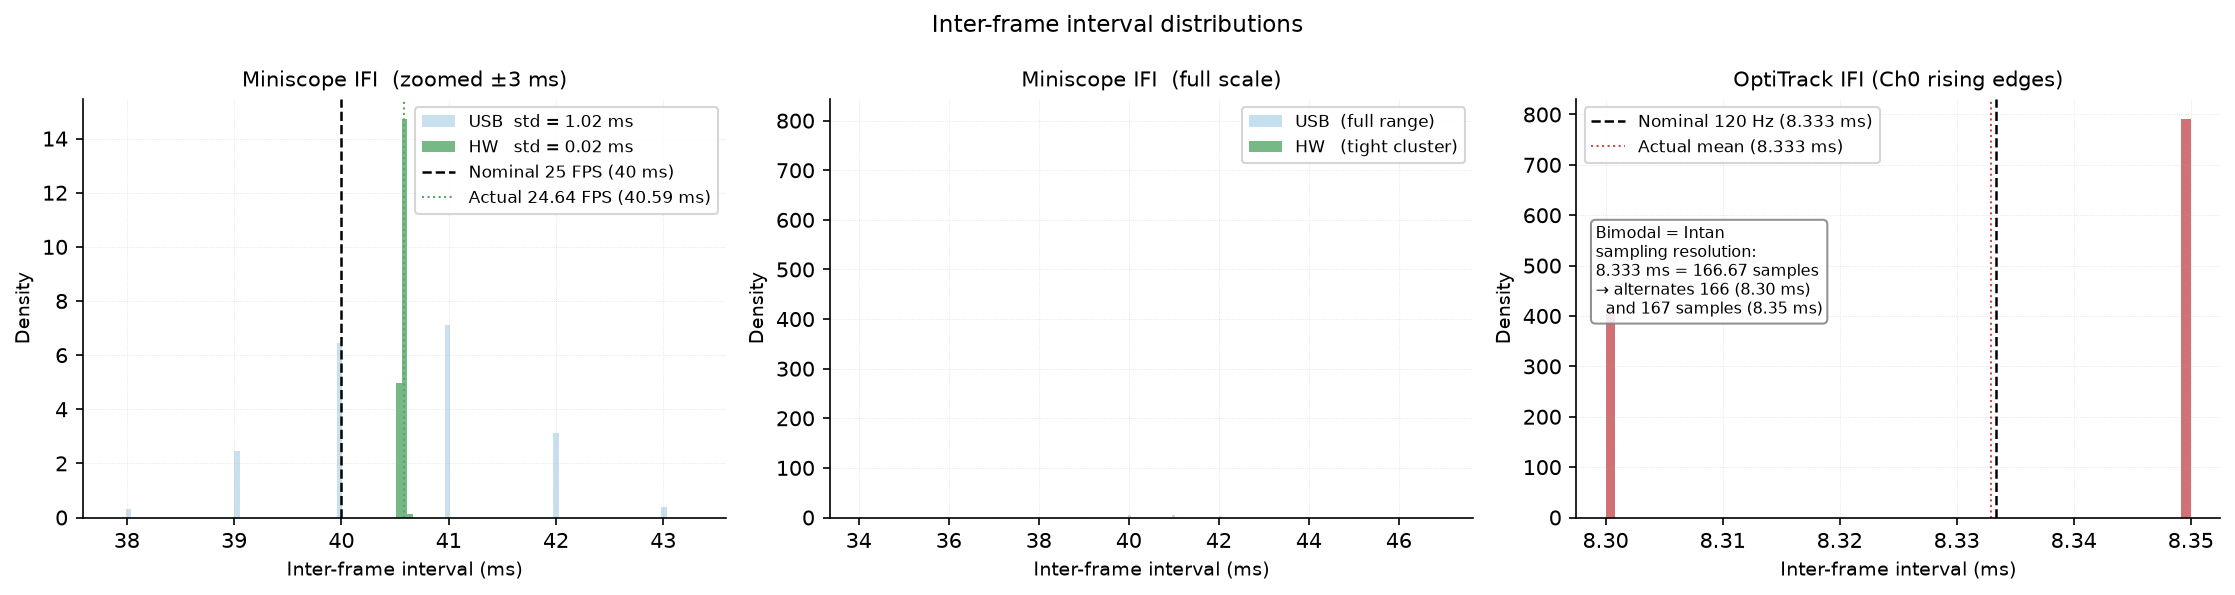

Miniscope actual frame rate: 24.6379 FPS  (nominal 25, IFI = 40.588 ± 0.022 ms HW, 1.02 ms USB)
OptiTrack actual rate:       120.0052 Hz  (IFI = 8.3330 ± 0.0237 ms)


In [8]:
ms_ifi_hw  = np.diff(ms_hw)  * 1000   # ms, from hardware sync
ms_ifi_usb = np.diff(ms_usb) * 1000   # ms, from USB timestamps
opt_ifi    = np.diff(opt_ts) * 1000   # ms, from hardware sync

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Inter-frame interval distributions", fontsize=11)

# ── Left: Miniscope IFI comparison (zoom to ±3 ms around mean) ──────────────
ax = axes[0]
centre = ms_ifi_hw.mean()
xlim   = (centre - 3.0, centre + 3.0)
bins   = np.linspace(*xlim, 120)
ax.hist(ms_ifi_usb, bins=bins, alpha=0.55, color=C_USB, density=True,
        label=f"USB  std = {ms_ifi_usb.std():.2f} ms")
ax.hist(ms_ifi_hw,  bins=bins, alpha=0.80, color=C_MS,  density=True,
        label=f"HW   std = {ms_ifi_hw.std():.2f} ms")
ax.axvline(1000/25,    color="black", ls="--", lw=1.2, label="Nominal 25 FPS (40 ms)")
ax.axvline(centre,     color=C_MS,   ls=":",  lw=1.0, label=f"Actual {1000/centre:.2f} FPS ({centre:.2f} ms)")
ax.set_xlim(*xlim)
ax.set_xlabel("Inter-frame interval (ms)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.set_title("Miniscope IFI  (zoomed ±3 ms)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(ls=":", lw=0.4, alpha=0.4)

# ── Middle: Miniscope IFI — full scale to show USB drift tails ───────────────
ax = axes[1]
ax.hist(ms_ifi_usb, bins=200, alpha=0.60, color=C_USB, density=True,
        label=f"USB  (full range)")
ax.hist(ms_ifi_hw,  bins=200, alpha=0.80, color=C_MS,  density=True,
        label=f"HW   (tight cluster)")
ax.set_xlabel("Inter-frame interval (ms)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.set_title("Miniscope IFI  (full scale)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(ls=":", lw=0.4, alpha=0.4)

# ── Right: OptiTrack IFI (note: bimodal = Intan sampling quantisation) ───────
ax = axes[2]
ax.hist(opt_ifi, bins=60, alpha=0.80, color=C_OPT, density=True)
ax.axvline(1000/120, color="black", ls="--", lw=1.2,
           label=f"Nominal 120 Hz ({1000/120:.3f} ms)")
ax.axvline(opt_ifi.mean(), color=C_OPT, ls=":", lw=1.0,
           label=f"Actual mean ({opt_ifi.mean():.3f} ms)")
ax.set_xlabel("Inter-frame interval (ms)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.set_title("OptiTrack IFI (Ch0 rising edges)", fontsize=10)
ax.legend(fontsize=8)
ax.text(0.03, 0.70,
    "Bimodal = Intan\nsampling resolution:\n"
    f"8.333 ms = 166.67 samples\n"
    f"→ alternates 166 ({166*DT*1000:.2f} ms)\n"
    f"  and 167 samples ({167*DT*1000:.2f} ms)",
    transform=ax.transAxes, fontsize=7.5, va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
ax.grid(ls=":", lw=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("sync_05_ifi_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Miniscope actual frame rate: {1000/ms_ifi_hw.mean():.4f} FPS  "
      f"(nominal 25, IFI = {ms_ifi_hw.mean():.3f} ± {ms_ifi_hw.std():.3f} ms HW, "
      f"{ms_ifi_usb.std():.2f} ms USB)")
print(f"OptiTrack actual rate:       {1000/opt_ifi.mean():.4f} Hz  "
      f"(IFI = {opt_ifi.mean():.4f} ± {opt_ifi.std():.4f} ms)")

## 6 — Three-system alignment: 2-second snapshot

A 2-second window midway through the session showing all three streams together.

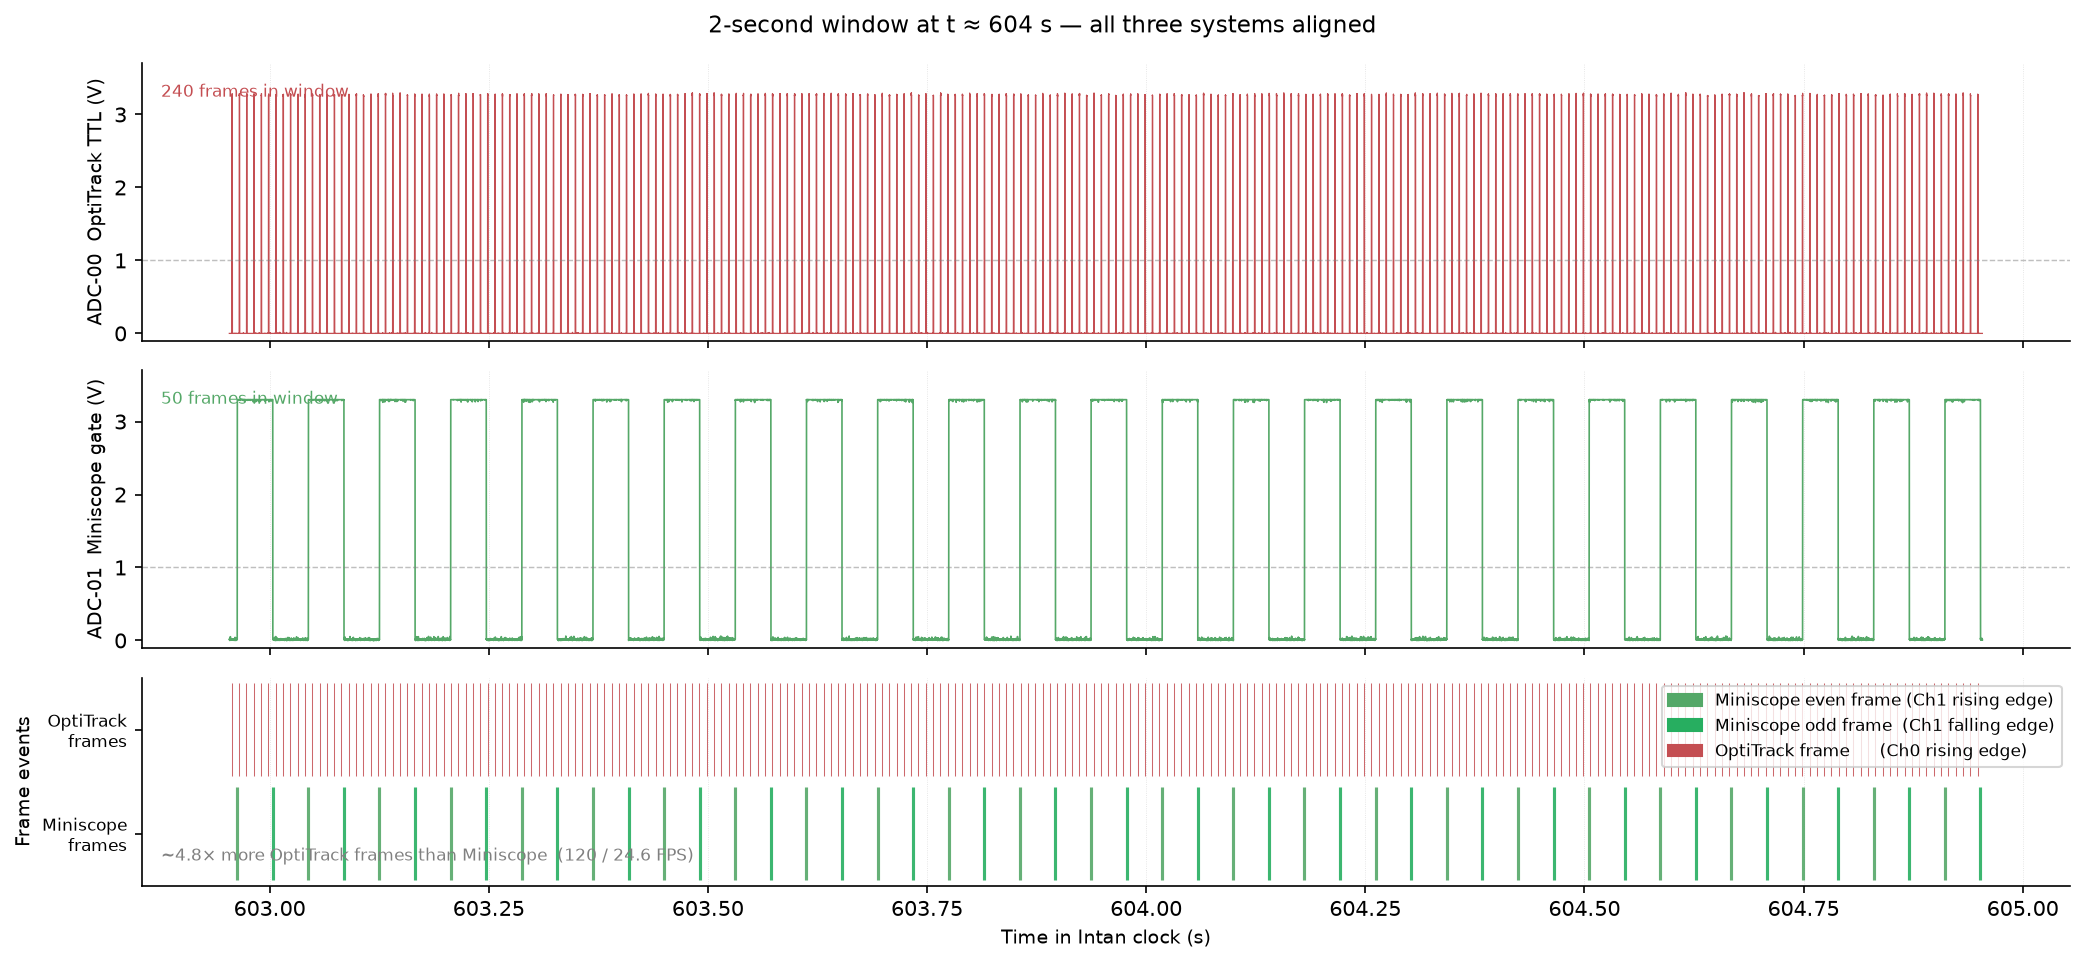

In [9]:
MID = (time_s[0] + time_s[-1]) / 2
W   = 1.0
T0m, T1m = MID - W, MID + W
mask_m   = (time_s >= T0m) & (time_s <= T1m)

ms_win  = ms_hw[ (ms_hw  >= T0m) & (ms_hw  <= T1m)]
opt_win = opt_ts[(opt_ts >= T0m) & (opt_ts <= T1m)]
ms_idx0 = np.searchsorted(ms_hw, T0m)

fig, axes = plt.subplots(3, 1, figsize=(14, 6.5), sharex=True,
                          gridspec_kw=dict(height_ratios=[1.2, 1.2, 0.9]))
fig.suptitle(f"2-second window at t ≈ {MID:.0f} s — all three systems aligned",
             fontsize=11)

# ADC-00 — OptiTrack: 0.5 ms pulses at 120 Hz are just barely resolved
# at this zoom; use raw plot so spikes are sharp
ax = axes[0]
ax.plot(time_s[mask_m], adc_v[mask_m, 0], lw=0.6, color=C_OPT, rasterized=True)
ax.set_ylabel("ADC-00  OptiTrack TTL (V)", fontsize=9)
ax.set_ylim(-0.1, 3.7)
ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5)
ax.text(0.01, 0.88, f"{len(opt_win)} frames in window",
        transform=ax.transAxes, fontsize=8, color=C_OPT)

# ADC-01 — Miniscope: 40 ms square waves clearly visible
ax = axes[1]
ax.plot(time_s[mask_m], adc_v[mask_m, 1], lw=0.8, color=C_MS)
ax.set_ylabel("ADC-01  Miniscope gate (V)", fontsize=9)
ax.set_ylim(-0.1, 3.7)
ax.axhline(THRESH, ls="--", lw=0.7, color="gray", alpha=0.5)
ax.text(0.01, 0.88, f"{len(ms_win)} frames in window",
        transform=ax.transAxes, fontsize=8, color=C_MS)

# Frame-event raster
ax = axes[2]
ax.vlines(opt_win, 1.05, 1.95, color=C_OPT, lw=0.5, alpha=0.85)
for k, t in enumerate(ms_win):
    fidx  = ms_idx0 + k
    color = C_MS if fidx % 2 == 0 else "#27AE60"
    ax.vlines(t, 0.05, 0.95, color=color, lw=1.5, alpha=0.9)

ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Miniscope\nframes", "OptiTrack\nframes"], fontsize=8)
ax.set_ylim(0, 2)

p_even = mpatches.Patch(color=C_MS,       label="Miniscope even frame (Ch1 rising edge)")
p_odd  = mpatches.Patch(color="#27AE60",  label="Miniscope odd frame  (Ch1 falling edge)")
p_opt  = mpatches.Patch(color=C_OPT,     label="OptiTrack frame      (Ch0 rising edge)")
ax.legend(handles=[p_even, p_odd, p_opt], fontsize=8, loc="upper right")
ax.set_ylabel("Frame events", fontsize=9)

# Show ratio annotation
ratio = len(opt_win) / max(len(ms_win), 1)
ax.text(0.01, 0.12,
        f"~{ratio:.1f}× more OptiTrack frames than Miniscope  "
        f"(120 / {1000/ms_ifi_hw.mean():.1f} FPS)",
        transform=ax.transAxes, fontsize=8, color="gray")

for ax in axes:
    ax.grid(axis="x", ls=":", lw=0.4, alpha=0.4)

axes[2].set_xlabel("Time in Intan clock (s)", fontsize=9)
plt.tight_layout()
plt.savefig("sync_06_midwindow.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — Cumulative frame coverage

A perfectly straight line means zero dropped sync pulses. Any step or kink would indicate a missed frame.

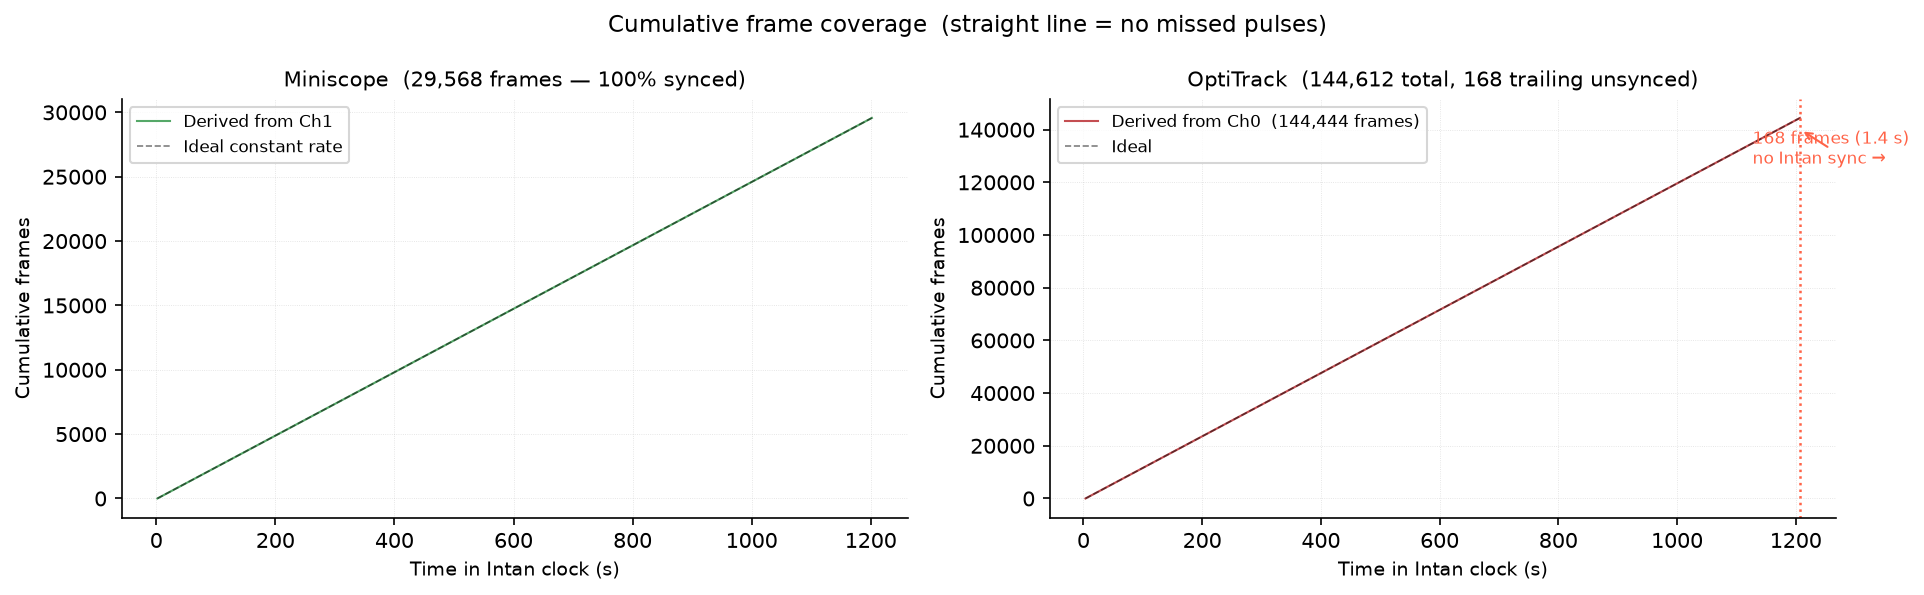

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Cumulative frame coverage  (straight line = no missed pulses)", fontsize=11)

# Miniscope
ax = axes[0]
ideal_ms = np.linspace(ms_hw[0], ms_hw[-1], len(ms_hw))
ax.plot(ms_hw,    np.arange(len(ms_hw)), color=C_MS,    lw=1.0, label="Derived from Ch1")
ax.plot(ideal_ms, np.arange(len(ms_hw)), color="black", lw=0.8, ls="--",
        alpha=0.5, label="Ideal constant rate")
ax.set_xlabel("Time in Intan clock (s)", fontsize=9)
ax.set_ylabel("Cumulative frames", fontsize=9)
ax.set_title(f"Miniscope  ({len(ms_hw):,} frames — 100% synced)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(ls=":", lw=0.4, alpha=0.4)

# OptiTrack
N_TRACK = 144_612     # total frames in OptiTrack file
N_UNSYNCED = N_TRACK - len(opt_ts)
ax = axes[1]
ideal_opt = np.linspace(opt_ts[0], opt_ts[-1], len(opt_ts))
ax.plot(opt_ts,    np.arange(len(opt_ts)), color=C_OPT,   lw=1.0,
        label=f"Derived from Ch0  ({len(opt_ts):,} frames)")
ax.plot(ideal_opt, np.arange(len(opt_ts)), color="black",  lw=0.8, ls="--",
        alpha=0.5, label="Ideal")

# Show where Intan ends and the unsynced tail begins
ax.axvline(opt_ts[-1], color="tomato", lw=1.2, ls=":")
ax.annotate(
    f"{N_UNSYNCED} frames ({N_UNSYNCED/120:.1f} s)\nno Intan sync →",
    xy=(opt_ts[-1], len(opt_ts) * 0.97),
    xytext=(opt_ts[-1] - 80, len(opt_ts) * 0.88),
    fontsize=8, color="tomato",
    arrowprops=dict(arrowstyle="->", color="tomato", lw=1.0))

ax.set_xlabel("Time in Intan clock (s)", fontsize=9)
ax.set_ylabel("Cumulative frames", fontsize=9)
ax.set_title(f"OptiTrack  ({N_TRACK:,} total, {N_UNSYNCED} trailing unsynced)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(ls=":", lw=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("sync_07_cumulative_frames.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 — Summary: the synchronised timestamps for NWB

The analysis above produces the timestamp arrays that go into the NWB file.

In [11]:
print("=" * 62)
print("NWB TIMESTAMPS (all in Intan clock, seconds)")
print("=" * 62)
print(f"\nOnePhotonSeries  (raw Miniscope video):")
print(f"  timestamps : shape {ms_hw.shape}")
print(f"  range      : {ms_hw[0]:.4f} – {ms_hw[-1]:.4f} s")
print(f"  frame rate : {len(ms_hw) / (ms_hw[-1]-ms_hw[0]):.4f} FPS  (do NOT use rate=25.0)")
print(f"  coverage   : 100 % (all frames via Ch1 rising+falling edges)")

print(f"\nSpatialSeries   (OptiTrack position):")
print(f"  timestamps : shape {opt_ts.shape}")
print(f"  range      : {opt_ts[0]:.4f} – {opt_ts[-1]:.4f} s")
print(f"  frame rate : {1/np.diff(opt_ts).mean():.2f} Hz")
print(f"  coverage   : {len(opt_ts)/N_TRACK*100:.2f} %  ({N_UNSYNCED} trailing frames unsynced)")

print(f"\nSession overlap (all three systems active):")
ol_s = max(ms_hw[0], opt_ts[0])
ol_e = min(ms_hw[-1], opt_ts[-1])
print(f"  {ol_s:.2f} → {ol_e:.2f} s   ({ol_e-ol_s:.1f} s = {(ol_e-ol_s)/60:.1f} min)")

print(f"\nKey: do NOT use Miniscope timeStamps.csv for NWB.")
print(f"     Clock drift = {ppm:.0f} ppm → max error = {np.abs(residual).max():.0f} ms over session.")

NWB TIMESTAMPS (all in Intan clock, seconds)

OnePhotonSeries  (raw Miniscope video):
  timestamps : shape (29568,)
  range      : 1.8567 – 1201.9180 s
  frame rate : 24.6387 FPS  (do NOT use rate=25.0)
  coverage   : 100 % (all frames via Ch1 rising+falling edges)

SpatialSeries   (OptiTrack position):
  timestamps : shape (144444,)
  range      : 3.4578 – 1207.0975 s
  frame rate : 120.01 Hz
  coverage   : 99.88 %  (168 trailing frames unsynced)

Session overlap (all three systems active):
  3.46 → 1201.92 s   (1198.5 s = 20.0 min)

Key: do NOT use Miniscope timeStamps.csv for NWB.
     Clock drift = 175 ppm → max error = 236 ms over session.
